
# NPD validation notebook for DIF-PI

This notebook isolates the **Next Purchase Day (NPD)** validation stage of DIF-PI and adapts the evaluation logic from the paper **“Transformer-Based Model for Predicting Customers’ Next Purchase Day in e-Commerce”** to the same processed transaction dataset used by the DIF-PI / SDG validation workflow.

The notebook focuses on:

1. loading the processed transaction export created by `eda-complete-journey.ipynb`;
2. converting customer purchase histories into **inter-purchase-gap** sequences;
3. reproducing the paper-style experiments with:
   - **AutoTS / ARIMA** baseline,
   - **XGBoost** baseline,
   - **LSTM** baseline,
   - **Transformer** baseline,
   - **Clustered Transformer** variant;
4. benchmarking the models on the **next 5 purchase gaps**;
5. exporting the results needed for the thesis chapter and appendices.



## 1) Environment and validation configuration

This section defines the paths, the customer eligibility filters, the paper-aligned NPD horizon, and the clustering / model settings.


In [12]:
from pathlib import Path
import json
import sys
import platform
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller

REPO_ROOT = Path('.').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.npd import NPDModel
from src.autots import AutoTSNPDRegressor
from src.npd_baselines import XGBoostNPDRegressor, LSTMNPDRegressor

TRANSFORMER_MODULE_CANDIDATES = [
    REPO_ROOT / 'src' / 'transformer_forecaster.py',
    REPO_ROOT / 'transformer_forecaster.py',
    Path('/mnt/data/transformer_forecaster.py'),
]

NPDTransformerForecaster = None
TRANSFORMER_MODULE_DESC = None
for candidate in TRANSFORMER_MODULE_CANDIDATES:
    if not candidate.exists():
        continue
    spec = importlib.util.spec_from_file_location('transformer_forecaster_dynamic', candidate)
    if spec is None or spec.loader is None:
        continue
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    NPDTransformerForecaster = module.NPDTransformerForecaster
    TRANSFORMER_MODULE_DESC = str(candidate)
    break

if NPDTransformerForecaster is None:
    from src.transformer_forecaster import NPDTransformerForecaster
    TRANSFORMER_MODULE_DESC = 'src.transformer_forecaster'

TX_PATH = REPO_ROOT / 'datasets' / 'processed' / 'difpi_transactions.csv'
OUT_DIR = REPO_ROOT / 'artifacts' / 'npd_validation'
OUT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_ROOT = REPO_ROOT / 'artifacts' / 'models' / 'npd_transformer_bundle'
GLOBAL_MODEL_DIR = ARTIFACT_ROOT / 'global_transformer'
CLUSTER_MODEL_ROOT = ARTIFACT_ROOT / 'cluster_transformers'

CUST_COL = 'CustomerID'
DATE_COL = 'InvoiceDate'
SKU_COL = 'StockCode'
QTY_COL = 'Quantity'
UNITP_COL = 'UnitPrice'

SEED = 42
np.random.seed(SEED)

# Paper-aligned NPD settings, upgraded to direct multi-step forecasting with longer context
FORECAST_HORIZON = 5          # predict the next 5 purchase gaps directly
DIRECT_OUTPUT_HORIZON = FORECAST_HORIZON
WINDOW_SIZE = 12              # increased lookback context versus the original 5-gap setup
MIN_PURCHASE_DAYS = 20        # same minimum-length spirit as the paper
N_CLUSTERS = 4                # elbow-method target from the paper
TEST_CUSTOMER_FRAC = 0.20

# Baseline / model settings
AUTOTS_MAX_P = 3
AUTOTS_MAX_D = 1
AUTOTS_MAX_Q = 3

INPUT_LENGTH_XGB = max(FORECAST_HORIZON * 2, WINDOW_SIZE)
XGB_ESTIMATORS = 1000
XGB_LEARNING_RATE = 0.3

LSTM_HIDDEN_DIM = 64
LSTM_EPOCHS = 300
LSTM_BATCH_SIZE = 8

TRANSFORMER_EPOCHS = 100
TRANSFORMER_SIZE_LAYER = 128
TRANSFORMER_EMBEDDED_SIZE = 128
TRANSFORMER_NUM_HEADS = 8
TRANSFORMER_DROPOUT = 0.10
TRANSFORMER_BATCH_SIZE = 32
TRANSFORMER_LR = 1e-3

print('PLATFORM:', platform.platform())
print('TX_PATH:', TX_PATH)
print('OUT_DIR:', OUT_DIR)
print('ARTIFACT_ROOT:', ARTIFACT_ROOT)
print('TRANSFORMER_MODULE:', TRANSFORMER_MODULE_DESC)
print('WINDOW_SIZE:', WINDOW_SIZE, '| DIRECT_OUTPUT_HORIZON:', DIRECT_OUTPUT_HORIZON)

PLATFORM: macOS-26.3.1-arm64-arm-64bit
TX_PATH: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/difpi_transactions.csv
OUT_DIR: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/npd_validation
ARTIFACT_ROOT: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/npd_transformer_bundle
TRANSFORMER_MODULE: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/src/transformer_forecaster.py
WINDOW_SIZE: 12 | DIRECT_OUTPUT_HORIZON: 5



## 2) Data loading

The notebook expects the same processed transactions export used by DIF-PI. Only the transaction table is needed because NPD is modeled from the sequence of purchase dates per customer.


In [13]:
if not TX_PATH.exists():
    raise FileNotFoundError(f"Missing {TX_PATH}. Run the EDA notebook first.")

tx = pd.read_csv(TX_PATH)
tx[CUST_COL] = tx[CUST_COL].astype(str)
tx[DATE_COL] = pd.to_datetime(tx[DATE_COL], errors='raise')
tx = tx.sort_values([CUST_COL, DATE_COL]).reset_index(drop=True)

req_cols = {CUST_COL, DATE_COL}
if not req_cols.issubset(tx.columns):
    raise ValueError(f"Transactions missing columns: {sorted(req_cols - set(tx.columns))}")

print("Transactions:", len(tx), "| customers:", tx[CUST_COL].nunique())
display(tx.head())

Transactions: 2576815 | customers: 2500


,CustomerID,InvoiceDate,StockCode,Quantity,UnitPrice
0,1,2018-02-21,825123,1,3.99
1,1,2018-02-21,831447,1,2.99
2,1,2018-02-21,840361,1,1.09
3,1,2018-02-21,845307,1,3.71
4,1,2018-02-21,852014,1,2.79



## 3) Customer purchase-gap sequences and behavioral descriptors

Each customer history is converted into a series of **days between consecutive purchase days**.  
The same section also computes the behavioral descriptors used for clustering and case-customer selection.


Eligible customers: 2198


,CustomerID,purchase_days,n_gaps,recency,frequency,avg_gap,std_gap,cv_gap,last_gap
0,900,521,520,0.0,521,1.248077,0.586709,0.470090,1.0
1,1510,504,503,0.0,504,1.250497,0.588892,0.470926,1.0
2,1795,494,493,1.0,494,1.259635,0.602171,0.478052,2.0
3,1228,469,468,0.0,469,1.497863,0.851090,0.568202,1.0
4,853,451,450,1.0,451,1.433333,1.137737,0.793769,3.0


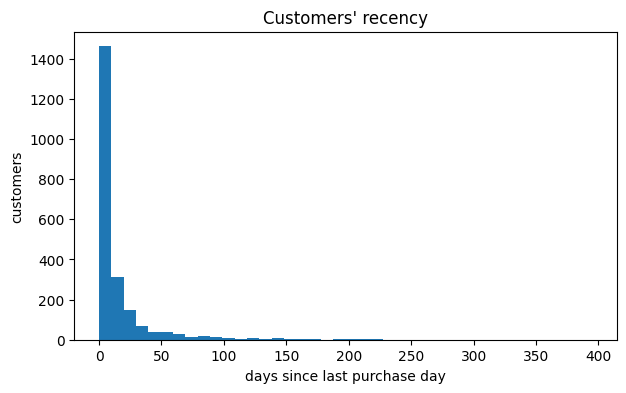

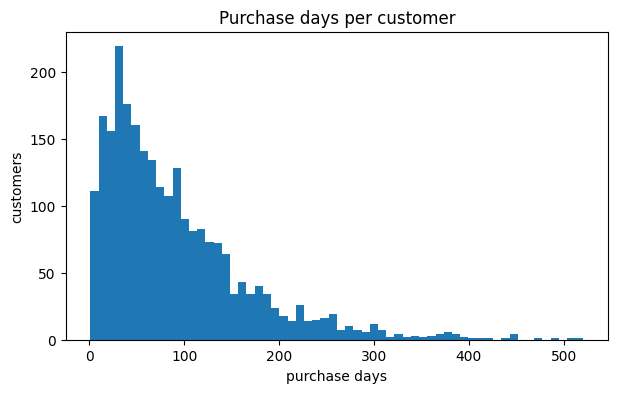

In [14]:
def build_customer_gap_sequences(tx_df, cust_col=CUST_COL, date_col=DATE_COL, min_purchase_days=MIN_PURCHASE_DAYS):
    sequences = {}
    meta_rows = []

    purchase_day_counts = (tx_df.groupby([cust_col, tx_df[date_col].dt.normalize()])
                             .size()
                             .reset_index(name='n_lines')
                             .groupby(cust_col)
                             .size())

    global_last_day = tx_df[date_col].max().normalize()

    for cust, g in tx_df[[cust_col, date_col]].dropna().sort_values([cust_col, date_col]).groupby(cust_col):
        days = pd.Series(g[date_col].dt.normalize().unique()).sort_values().reset_index(drop=True)
        if len(days) < int(min_purchase_days):
            continue

        gaps = days.diff().dropna().dt.days.astype(float).values
        if len(gaps) < WINDOW_SIZE + FORECAST_HORIZON:
            continue

        recency = float((global_last_day - days.iloc[-1]).days)
        frequency = int(len(days))
        avg_gap = float(np.mean(gaps))
        std_gap = float(np.std(gaps))
        cv_gap = float(std_gap / (avg_gap + 1e-6))
        last_gap = float(gaps[-1])

        sequences[str(cust)] = gaps
        meta_rows.append({
            CUST_COL: str(cust),
            'purchase_days': int(len(days)),
            'n_gaps': int(len(gaps)),
            'recency': recency,
            'frequency': frequency,
            'avg_gap': avg_gap,
            'std_gap': std_gap,
            'cv_gap': cv_gap,
            'last_gap': last_gap,
        })

    meta_df = pd.DataFrame(meta_rows).sort_values(['frequency', 'purchase_days'], ascending=False).reset_index(drop=True)
    return sequences, meta_df, purchase_day_counts

gap_sequences, customer_meta, purchase_days = build_customer_gap_sequences(tx)

print("Eligible customers:", len(gap_sequences))
display(customer_meta.head())

plt.figure(figsize=(7, 4))
plt.hist(customer_meta['recency'], bins=40)
plt.title('Customers\' recency')
plt.xlabel('days since last purchase day')
plt.ylabel('customers')
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(purchase_days.values, bins=60)
plt.title('Purchase days per customer')
plt.xlabel('purchase days')
plt.ylabel('customers')
plt.show()


## 4) Customer split, elbow method, and cluster assignment

The clustered Transformer follows the same logic as the paper: customers are grouped by behavioral descriptors, and a dedicated Transformer is trained for each cluster.


,k,sse
0,2,7203.337672
1,3,6129.745782
2,4,5202.172730
3,5,4416.485687
4,6,3654.567202
5,7,3249.861590
6,8,2957.452449


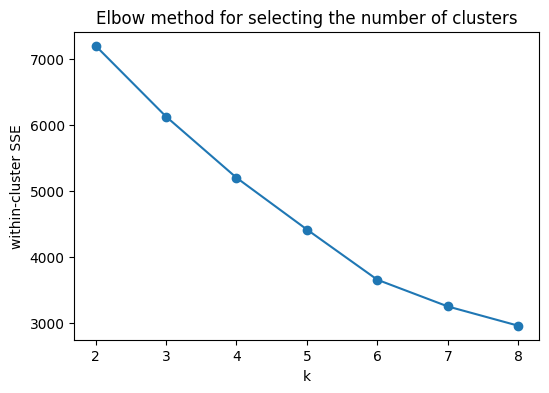

Train customers: 1758 | Test customers: 440


,CustomerID,purchase_days,n_gaps,recency,frequency,avg_gap,std_gap,cv_gap,last_gap,cluster
0,900,521,520,0.0,521,1.248077,0.586709,0.470090,1.0,1
1,1510,504,503,0.0,504,1.250497,0.588892,0.470926,1.0,2
2,1795,494,493,1.0,494,1.259635,0.602171,0.478052,2.0,0
3,1228,469,468,0.0,469,1.497863,0.851090,0.568202,1.0,1
4,853,451,450,1.0,451,1.433333,1.137737,0.793769,3.0,0


In [15]:
eligible_customers = customer_meta[CUST_COL].astype(str).tolist()
rng = np.random.default_rng(SEED)
rng.shuffle(eligible_customers)

n_test = max(1, int(round(len(eligible_customers) * TEST_CUSTOMER_FRAC)))
TEST_CUSTOMERS = sorted(eligible_customers[:n_test])
TRAIN_CUSTOMERS = sorted(eligible_customers[n_test:])

feature_cols = ['recency', 'frequency', 'avg_gap', 'std_gap', 'cv_gap', 'last_gap']
feature_scaler = StandardScaler()
train_feature_matrix = feature_scaler.fit_transform(
    customer_meta.set_index(CUST_COL).loc[TRAIN_CUSTOMERS, feature_cols]
)

sse_rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(train_feature_matrix)
    sse_rows.append({'k': k, 'sse': float(km.inertia_)})

elbow_df = pd.DataFrame(sse_rows)
display(elbow_df)

plt.figure(figsize=(6, 4))
plt.plot(elbow_df['k'], elbow_df['sse'], marker='o')
plt.title('Elbow method for selecting the number of clusters')
plt.xlabel('k')
plt.ylabel('within-cluster SSE')
plt.show()

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
kmeans.fit(train_feature_matrix)

customer_meta = customer_meta.copy()
customer_meta['cluster'] = -1
customer_meta.loc[customer_meta[CUST_COL].isin(TRAIN_CUSTOMERS), 'cluster'] = kmeans.labels_

test_feature_matrix = feature_scaler.transform(
    customer_meta.set_index(CUST_COL).loc[TEST_CUSTOMERS, feature_cols]
)
customer_meta.loc[customer_meta[CUST_COL].isin(TEST_CUSTOMERS), 'cluster'] = kmeans.predict(test_feature_matrix)

print("Train customers:", len(TRAIN_CUSTOMERS), "| Test customers:", len(TEST_CUSTOMERS))
display(customer_meta.head())

pd.Series(TRAIN_CUSTOMERS, name='train_customer').to_csv(OUT_DIR / 'train_customers.csv', index=False)
pd.Series(TEST_CUSTOMERS, name='test_customer').to_csv(OUT_DIR / 'test_customers.csv', index=False)
customer_meta.to_csv(OUT_DIR / 'customer_meta_with_clusters.csv', index=False)

In [16]:
def load_cluster_transformers(cluster_root):
    cluster_models = {}
    cluster_root = Path(cluster_root)
    if not cluster_root.exists():
        return cluster_models

    for subdir in sorted(cluster_root.glob('cluster_*')):
        if not subdir.is_dir():
            continue
        try:
            cluster_id = int(subdir.name.split('_')[-1])
            cluster_models[cluster_id] = NPDTransformerForecaster.load(subdir)
            print(f"Loaded clustered transformer for cluster {cluster_id} from {subdir}")
        except Exception as exc:
            print(f"Skipping clustered transformer in {subdir}: {exc}")
    return cluster_models

if not GLOBAL_MODEL_DIR.exists():
    raise FileNotFoundError(
        f"Missing global NPD Transformer artifacts in {GLOBAL_MODEL_DIR}. Retrain the transformer bundle with the direct multi-step model first."
    )

global_transformer = NPDTransformerForecaster.load(GLOBAL_MODEL_DIR)
cluster_transformers = load_cluster_transformers(CLUSTER_MODEL_ROOT)

print('Loaded global_transformer from:', GLOBAL_MODEL_DIR)
print('Global transformer config:', {
    'input_length': getattr(global_transformer, 'input_length', None),
    'output_horizon': getattr(global_transformer, 'output_horizon', 1),
    'direct_multistep': bool(getattr(global_transformer, 'is_direct_multistep', False)),
})
if getattr(global_transformer, 'output_horizon', 1) < FORECAST_HORIZON:
    print('NOTE: the loaded global Transformer artifact is still single-step. Forecasting will still run, but it will fall back to recursive behaviour. Retrain to get true direct multi-step results.')
print('Loaded cluster_transformers:', sorted(cluster_transformers.keys()))

Loaded clustered transformer for cluster 0 from /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/npd_transformer_bundle/cluster_transformers/cluster_0
Loaded clustered transformer for cluster 1 from /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/npd_transformer_bundle/cluster_transformers/cluster_1
Loaded clustered transformer for cluster 2 from /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/npd_transformer_bundle/cluster_transformers/cluster_2
Loaded clustered transformer for cluster 3 from /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/npd_transformer_bundle/cluster_transformers/cluster_3
Loaded global_transformer from: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/npd_transformer


## 5) Case customers and visualization

Two case customers are selected to mirror the article’s qualitative examples:
- one with **lower purchase frequency**,
- one with **higher purchase frequency**.


CASE_CUSTOMER_LOW: 610
CASE_CUSTOMER_HIGH: 1510


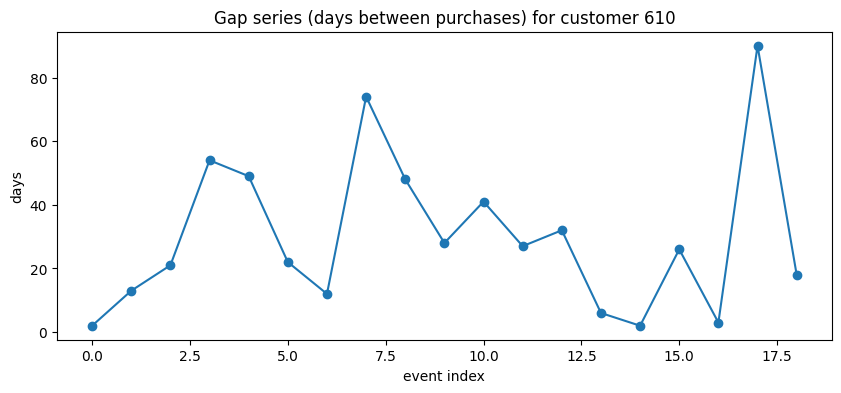

ADF p-value for customer 610: 0.011716


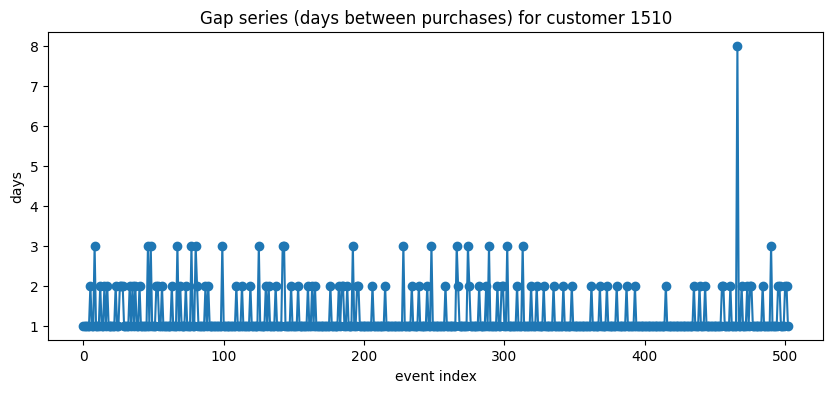

ADF p-value for customer 1510: 0.000000


In [17]:
test_meta = customer_meta[customer_meta[CUST_COL].isin(TEST_CUSTOMERS)].copy().sort_values('frequency')
if len(test_meta) < 2:
    raise ValueError("Need at least two eligible test customers for the case-study plots.")

CASE_CUSTOMER_LOW = str(test_meta.iloc[0][CUST_COL])
CASE_CUSTOMER_HIGH = str(test_meta.iloc[-1][CUST_COL])
CASE_CUSTOMERS = [CASE_CUSTOMER_LOW, CASE_CUSTOMER_HIGH]

print("CASE_CUSTOMER_LOW:", CASE_CUSTOMER_LOW)
print("CASE_CUSTOMER_HIGH:", CASE_CUSTOMER_HIGH)

for cust in CASE_CUSTOMERS:
    series = gap_sequences[cust]
    plt.figure(figsize=(10, 4))
    plt.plot(series, marker='o')
    plt.title(f'Gap series (days between purchases) for customer {cust}')
    plt.xlabel('event index')
    plt.ylabel('days')
    plt.show()

    try:
        adf_pvalue = float(adfuller(series)[1])
    except Exception:
        adf_pvalue = np.nan
    print(f"ADF p-value for customer {cust}: {adf_pvalue:.6f}")


## 6) Model helpers

The helpers below evaluate all paper-aligned models on the same held-out horizon.  
For the clustered Transformer, one model is trained per cluster using pooled training windows from the customers assigned to that cluster.


In [18]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def prepare_train_test_gap_split(series, horizon=FORECAST_HORIZON):
    arr = np.asarray(series, dtype=float).reshape(-1)
    if len(arr) <= int(horizon):
        raise ValueError('Series too short for the requested forecast horizon.')
    history = arr[:-int(horizon)]
    future = arr[-int(horizon):]
    return history, future

def forecast_all_models_for_customer(customer_id, gap_sequences, customer_meta):
    series = gap_sequences[str(customer_id)]
    history, future = prepare_train_test_gap_split(series, horizon=FORECAST_HORIZON)

    min_required_history = max(8, WINDOW_SIZE, INPUT_LENGTH_XGB, getattr(global_transformer, 'input_length', WINDOW_SIZE))
    if len(history) < min_required_history:
        raise ValueError(
            f'Customer {customer_id} has only {len(history)} history gaps; need at least {min_required_history}.'
        )

    model_arima = AutoTSNPDRegressor(
        forecast_length=FORECAST_HORIZON,
        max_p=AUTOTS_MAX_P,
        max_d=AUTOTS_MAX_D,
        max_q=AUTOTS_MAX_Q,
        verbose=0,
    ).fit_series(history)

    model_xgb = XGBoostNPDRegressor(
        input_length=INPUT_LENGTH_XGB,
        n_estimators=XGB_ESTIMATORS,
        learning_rate=XGB_LEARNING_RATE,
        random_state=SEED,
    ).fit_series(history)

    model_lstm = LSTMNPDRegressor(
        input_length=WINDOW_SIZE,
        hidden_dim=LSTM_HIDDEN_DIM,
        epochs=LSTM_EPOCHS,
        batch_size=LSTM_BATCH_SIZE,
        seed=SEED,
    ).fit_series(history, verbose=False)

    preds = {
        'ARIMA_AutoTS': model_arima.forecast_series(history, FORECAST_HORIZON),
        'XGBoost': model_xgb.forecast_series(history, FORECAST_HORIZON),
        'LSTM': model_lstm.forecast_series(history, FORECAST_HORIZON),
        'Transformer': global_transformer.forecast_series(history, FORECAST_HORIZON),
    }

    cluster_id = int(customer_meta.set_index(CUST_COL).loc[str(customer_id), 'cluster'])
    cluster_model = cluster_transformers.get(cluster_id, None)
    if cluster_model is not None:
        preds['Transformer_Clustered'] = cluster_model.forecast_series(history, FORECAST_HORIZON)

    rows = []
    for model_name, pred in preds.items():
        rows.append({
            CUST_COL: str(customer_id),
            'model': model_name,
            'history_len': int(len(history)),
            'model_backend': getattr(model_arima, 'backend_', 'unknown') if model_name == 'ARIMA_AutoTS' else '',
            'transformer_mode': (
                f"direct_{getattr(global_transformer, 'output_horizon', 1)}step"
                if model_name == 'Transformer' and getattr(global_transformer, 'output_horizon', 1) > 1
                else ('recursive_1step' if model_name == 'Transformer' else '')
            ),
            'mae': float(mean_absolute_error(future, pred)),
            'rmse': rmse(future, pred),
            'true_future': future.tolist(),
            'pred_future': np.asarray(pred, dtype=float).tolist(),
        })
    return pd.DataFrame(rows), history, future, preds


## 7) Single-customer case studies

This section reproduces the paper-style qualitative analysis for the two selected customers and exports the detailed forecast tables.


/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  war

,model,mae,rmse
0,ARIMA_AutoTS,22.855199,32.964971
3,Transformer,23.476319,35.455616
4,Transformer_Clustered,24.047966,37.378680
1,XGBoost,24.999822,39.183676
2,LSTM,26.800000,42.047592


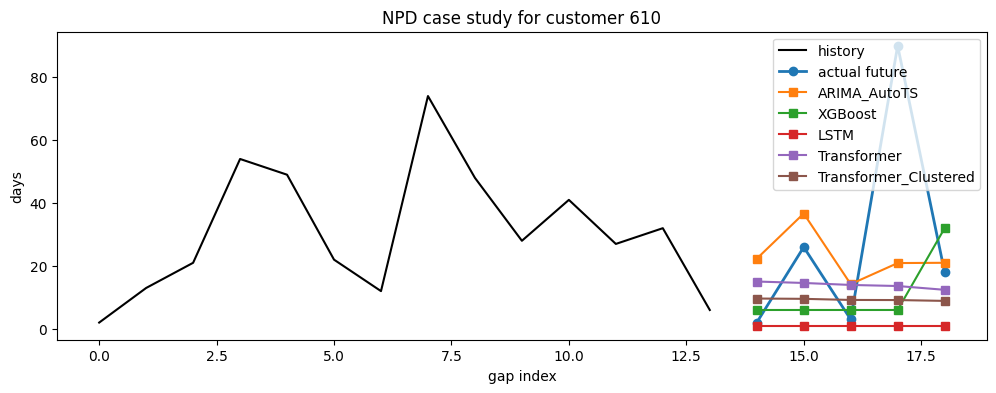

Template Eval Error: ValueError("regression_type='User' but future_regressor not supplied") in model 3 in generation 0: ARIMA
Template Eval Error: ValueError("regression_type='User' but future_regressor not supplied") in model 5 in generation 0: ARIMA
Template Eval Error: ValueError("regression_type='User' but future_regressor not supplied") in model 6 in generation 0: ARIMA


,model,mae,rmse
1,XGBoost,0.247320,0.438201
0,ARIMA_AutoTS,0.332487,0.463735
3,Transformer,0.487383,0.489949
2,LSTM,0.344056,0.502789
4,Transformer_Clustered,0.568940,0.647394


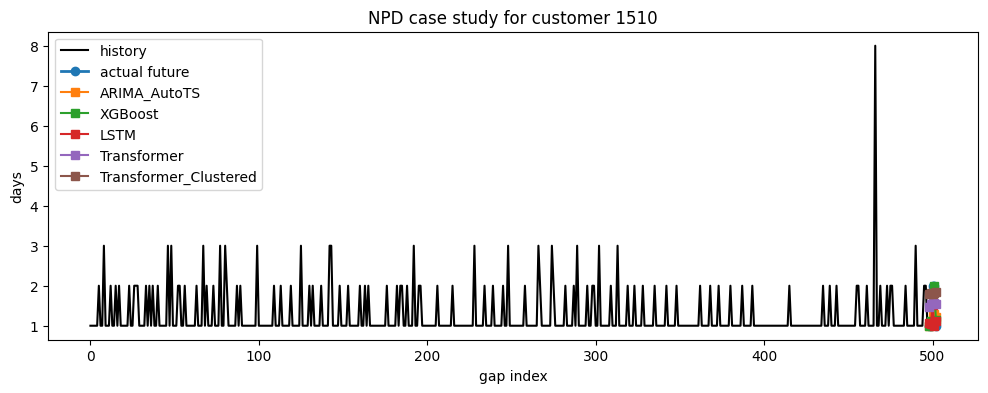

,CustomerID,model,history_len,model_backend,transformer_mode,mae,rmse,true_future,pred_future
0,610,ARIMA_AutoTS,14,sarimax_grid,,22.855199,32.964971,"[2.0, 26.0, 3.0, 90.0, 18.0]","[22.299661699846958, 36.668578323304686, 14.21..."
1,610,XGBoost,14,,,24.999822,39.183676,"[2.0, 26.0, 3.0, 90.0, 18.0]","[6.000890254974365, 6.000890254974365, 6.00089..."
2,610,LSTM,14,,,26.800000,42.047592,"[2.0, 26.0, 3.0, 90.0, 18.0]","[1.0, 1.0, 1.0, 1.0, 1.0]"
3,610,Transformer,14,,direct_5step,23.476319,35.455616,"[2.0, 26.0, 3.0, 90.0, 18.0]","[15.046089982646524, 14.59225235994976, 13.961..."
4,610,Transformer_Clustered,14,,,24.047966,37.378680,"[2.0, 26.0, 3.0, 90.0, 18.0]","[9.641054994817448, 9.54511162672845, 9.192579..."


In [19]:
case_rows = []
case_payload = {}

for cust in CASE_CUSTOMERS:
    case_df, history, future, preds = forecast_all_models_for_customer(cust, gap_sequences, customer_meta)
    case_rows.append(case_df)
    case_payload[str(cust)] = {
        'history': np.asarray(history, dtype=float).tolist(),
        'future': np.asarray(future, dtype=float).tolist(),
        'predictions': {k: np.asarray(v, dtype=float).tolist() for k, v in preds.items()},
    }

    display(case_df[['model', 'mae', 'rmse']].sort_values('rmse'))

    plt.figure(figsize=(12, 4))
    x_hist = np.arange(len(history))
    x_future = np.arange(len(history), len(history) + len(future))
    plt.plot(x_hist, history, label='history', color='black')
    plt.plot(x_future, future, label='actual future', marker='o', linewidth=2)
    for model_name, pred in preds.items():
        plt.plot(x_future, pred, label=model_name, marker='s')
    plt.title(f'NPD case study for customer {cust}')
    plt.xlabel('gap index')
    plt.ylabel('days')
    plt.legend()
    plt.show()

case_results_df = pd.concat(case_rows, ignore_index=True)
case_results_df.to_csv(OUT_DIR / 'npd_case_results.csv', index=False)
(OUT_DIR / 'npd_case_payload.json').write_text(json.dumps(case_payload, indent=2), encoding='utf-8')

display(case_results_df.head())


## 8) All-customer benchmark

The models are evaluated across all eligible **test customers**, and the mean RMSE / MAE are compared exactly as in the paper’s overall benchmark table.


In [23]:
all_rows = []
skipped_customers = []

for idx, cust in enumerate(TEST_CUSTOMERS, start=1):
    try:
        cust_df, _, _, _ = forecast_all_models_for_customer(cust, gap_sequences, customer_meta)
        all_rows.append(cust_df)
        print(f"Processed customer {idx} / {len(TEST_CUSTOMERS)}")
    except Exception as exc:
        skipped_customers.append({'customer_id': str(cust), 'error': str(exc)})
        print(f"Skipped customer {idx} / {len(TEST_CUSTOMERS)}: {cust} -> {exc}")

all_results_df = pd.concat(all_rows, ignore_index=True)
summary_df = (all_results_df.groupby('model', as_index=False)
              .agg(avg_mae=('mae', 'mean'),
                   avg_rmse=('rmse', 'mean'),
                   n_customers=(CUST_COL, 'nunique'))
              .sort_values('avg_rmse'))

display(summary_df)
all_results_df.to_csv(OUT_DIR / 'npd_all_customer_results.csv', index=False)
summary_df.to_csv(OUT_DIR / 'npd_summary.csv', index=False)

if skipped_customers:
    skipped_df = pd.DataFrame(skipped_customers)
    display(skipped_df.head())
    skipped_df.to_csv(OUT_DIR / 'npd_skipped_customers.csv', index=False)

Template Eval Error: ValueError("regression_type='User' but future_regressor not supplied") in model 3 in generation 0: ARIMA
Template Eval Error: ValueError("regression_type='User' but future_regressor not supplied") in model 5 in generation 0: ARIMA
Template Eval Error: ValueError("regression_type='User' but future_regressor not supplied") in model 6 in generation 0: ARIMA
Processed customer 1 / 440
Template Eval Error: Exception('Transformer Detrend failed on fit') in model 2 in generation 0: ARIMA
Template Eval Error: ValueError("regression_type='User' but future_regressor not supplied") in model 3 in generation 0: ARIMA
Template Eval Error: Exception('Transformer Detrend failed on fit') in model 4 in generation 0: ARIMA
Template Eval Error: ValueError("regression_type='User' but future_regressor not supplied") in model 5 in generation 0: ARIMA
Template Eval Error: ValueError("regression_type='User' but future_regressor not supplied") in model 6 in generation 0: ARIMA
Template Eval

,model,avg_mae,avg_rmse,n_customers
2,Transformer,8.291535,11.545185,440
3,Transformer_Clustered,8.465551,11.888449,440
4,XGBoost,11.621323,15.748432,440
1,LSTM,13.883988,17.745569,440
0,ARIMA_AutoTS,14.791131,18.390134,440


## 9) Comparison plots and purchase-intention view

The following cells generate the comparison plot used in the thesis chapter and a compact purchase-intention example based on the best-performing NPD model.


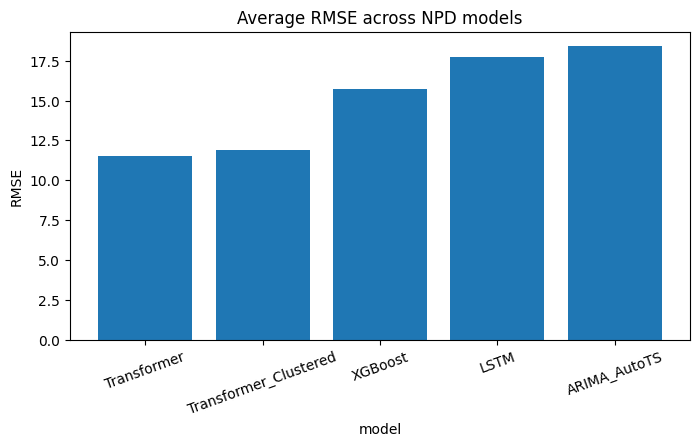

Best model by avg_rmse: Transformer


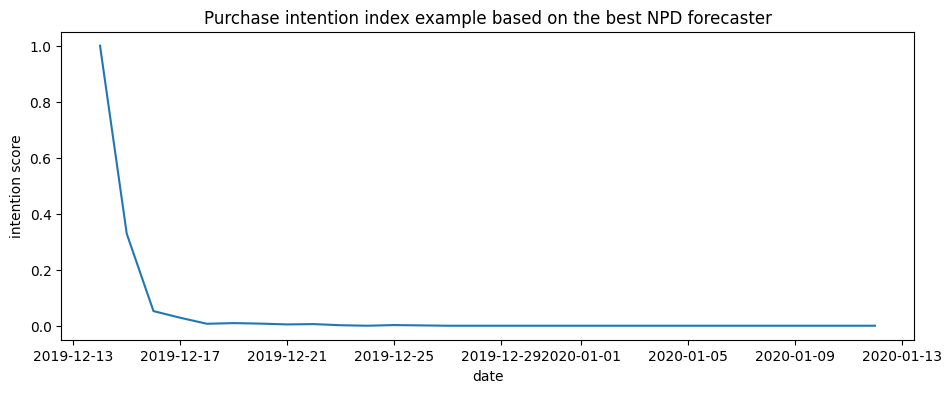

In [24]:
plt.figure(figsize=(8, 4))
plt.bar(summary_df['model'], summary_df['avg_rmse'])
plt.title('Average RMSE across NPD models')
plt.xlabel('model')
plt.ylabel('RMSE')
plt.xticks(rotation=20)
plt.show()

best_model_name = str(summary_df.iloc[0]['model'])
print('Best model by avg_rmse:', best_model_name)

# Fit the best model on the full pooled supervised dataset to build a purchase-intention index example.
best_window = getattr(global_transformer, 'input_length', WINDOW_SIZE)
npd = NPDModel(k=best_window, min_events=max(best_window + 2, 7), horizon=30)
X, y = npd.make_supervised(tx, cust_col=CUST_COL, date_col=DATE_COL)

if best_model_name == 'Transformer':
    best_model = global_transformer
elif best_model_name == 'Transformer_Clustered':
    # Reuse the loaded global transformer for the intention-index example because the index expects one model.
    best_model = global_transformer
elif best_model_name == 'XGBoost':
    best_model = XGBoostNPDRegressor(input_length=INPUT_LENGTH_XGB, n_estimators=XGB_ESTIMATORS, learning_rate=XGB_LEARNING_RATE, random_state=SEED)
    best_model.model.fit(X, y)
elif best_model_name == 'LSTM':
    best_model = LSTMNPDRegressor(input_length=WINDOW_SIZE, hidden_dim=LSTM_HIDDEN_DIM, epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH_SIZE, seed=SEED)
    best_model.value_mean_ = float(np.mean(np.concatenate([X.reshape(-1), y.reshape(-1)])))
    best_model.value_std_ = float(np.std(np.concatenate([X.reshape(-1), y.reshape(-1)])) + 1e-6)
    Xs = best_model._scale(X).astype(np.float32)
    ys = best_model._scale(y).astype(np.float32)
    import torch
    from torch.utils.data import DataLoader, TensorDataset
    dl = DataLoader(TensorDataset(torch.tensor(Xs).unsqueeze(-1), torch.tensor(ys)), batch_size=LSTM_BATCH_SIZE, shuffle=True)
    opt = torch.optim.Adam(best_model.model.parameters(), lr=best_model.lr)
    loss_fn = torch.nn.MSELoss()
    best_model.model.train()
    for _ in range(best_model.epochs):
        for xb, yb in dl:
            xb = xb.to(best_model.device); yb = yb.to(best_model.device)
            pred = best_model.model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad(); loss.backward(); opt.step()
else:
    # AutoTS / ARIMA is sequence-oriented, so purchase intention is illustrated with the loaded Transformer fallback for consistency.
    best_model = global_transformer

t0, intent = npd.intention_index(tx, best_model, cust_col=CUST_COL, date_col=DATE_COL, horizon=30)
plt.figure(figsize=(11, 4))
plt.plot(intent.index, intent.values)
plt.title('Purchase intention index example based on the best NPD forecaster')
plt.xlabel('date')
plt.ylabel('intention score')
plt.show()


## 10) Final summary paragraph

This cell generates a ready-to-use paragraph for the thesis / paper discussion section.


In [25]:
best_row = summary_df.sort_values('avg_rmse').iloc[0]
arima_row = summary_df[summary_df['model'] == 'ARIMA_AutoTS']
transformer_row = summary_df[summary_df['model'] == 'Transformer']
cluster_row = summary_df[summary_df['model'] == 'Transformer_Clustered']

improvement_vs_arima = np.nan
cluster_improvement_vs_arima = np.nan
if len(arima_row) and len(transformer_row):
    improvement_vs_arima = 100.0 * (float(arima_row.iloc[0]['avg_rmse']) - float(transformer_row.iloc[0]['avg_rmse'])) / float(arima_row.iloc[0]['avg_rmse'])
if len(arima_row) and len(cluster_row):
    cluster_improvement_vs_arima = 100.0 * (float(arima_row.iloc[0]['avg_rmse']) - float(cluster_row.iloc[0]['avg_rmse'])) / float(arima_row.iloc[0]['avg_rmse'])

summary_paragraph = (
    f"The NPD validation experiments performed on the DIF-PI transaction export show that {best_row['model']} "
    f"achieved the best average RMSE, with a value of {best_row['avg_rmse']:.4f} across {int(best_row['n_customers'])} test customers. "
    f"The comparison against the ARIMA / AutoTS baseline indicates an improvement of "
    f"{improvement_vs_arima:.2f}% for the Transformer model and {cluster_improvement_vs_arima:.2f}% for the clustered Transformer model, "
    f"when these rows are available in the aggregated summary. The case-customer plots confirm that the error differences are not uniform "
    f"across customer histories, which is consistent with the paper’s observation that stationary or more regular purchase-gap series are easier to forecast. "
    f"Overall, the notebook shows how the Transformer-based NPD component can be evaluated with the same processed DIF-PI dataset used by the other validation notebooks, "
    f"while keeping the paper-style comparison with ARIMA / AutoTS, XGBoost, LSTM, and the clustered Transformer variant."
)

print(summary_paragraph)
(OUT_DIR / 'npd_summary_paragraph.txt').write_text(summary_paragraph, encoding='utf-8')

The NPD validation experiments performed on the DIF-PI transaction export show that Transformer achieved the best average RMSE, with a value of 11.5452 across 440 test customers. The comparison against the ARIMA / AutoTS baseline indicates an improvement of 37.22% for the Transformer model and 35.35% for the clustered Transformer model, when these rows are available in the aggregated summary. The case-customer plots confirm that the error differences are not uniform across customer histories, which is consistent with the paper’s observation that stationary or more regular purchase-gap series are easier to forecast. Overall, the notebook shows how the Transformer-based NPD component can be evaluated with the same processed DIF-PI dataset used by the other validation notebooks, while keeping the paper-style comparison with ARIMA / AutoTS, XGBoost, LSTM, and the clustered Transformer variant.


902